In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import os
from dotenv import load_dotenv

load_dotenv()

url = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = sqlalchemy.create_engine(url)
df = pd.read_sql("SELECT * FROM cleaned_economic_data ORDER BY date", engine)
df.head()

,date,consumer_sentiment,cpi,fed_funds,gdp,unemployment
0,1954-07-01,NaN,26.86,0.80,390.996,5.8
1,1954-08-01,NaN,26.85,1.22,390.996,6.0
2,1954-09-01,NaN,26.81,1.07,390.996,6.1
3,1954-10-01,NaN,26.72,0.85,399.734,5.7
4,1954-11-01,87.0,26.78,0.83,399.734,5.3


## 1. Full Dataset Overview

In [4]:
print("Shape (rows, columns):", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape (rows, columns): (863, 6)

Column types:
 date                   object
consumer_sentiment    float64
cpi                   float64
fed_funds             float64
gdp                   float64
unemployment          float64
dtype: object

Missing values per column:
 date                    0
consumer_sentiment    197
cpi                     0
fed_funds               0
gdp                     0
unemployment            0
dtype: int64

Duplicate rows: 0


The cleaned dataset has 863 rows and 6 columns, covering monthly US economic
data. Five columns (cpi, unemployment, fed_funds, gdp, consumer_sentiment)
are numeric (float64); date is currently stored as a generic object type.

Only one column has missing data: consumer_sentiment, with 197 nulls
(about 23% of rows). This matches what was found during validation - FRED's
consumer sentiment series started reporting later than CPI, unemployment,
and fed funds, so early months in the dataset genuinely have no sentiment
value. This was a deliberate decision (documented in validate.py) to keep
these rows rather than drop them, since dropping would lose valid data in
the other 5 columns just because one feature is missing.

There are 0 duplicate rows, which confirms the pipeline's load step
(if_exists="replace") and the validation checks are working correctly -
re-running the pipeline never produces duplicate data.

## 2. Individual Column Analysis

In [5]:
df[["cpi", "unemployment", "fed_funds", "gdp", "consumer_sentiment"]].describe()

,cpi,unemployment,fed_funds,gdp,consumer_sentiment
count,863.000000,863.000000,863.000000,863.000000,666.000000
mean,135.600569,5.793627,4.597671,8667.957948,84.563514
std,88.724961,1.668236,3.533495,8366.629071,13.626246
min,26.710000,3.400000,0.050000,390.996000,44.800000
25%,41.750000,4.500000,1.920000,1278.467500,74.100000
50%,129.900000,5.500000,4.270000,5960.028000,88.450000
75%,212.696000,6.900000,6.120000,14564.117000,94.700000
max,333.979000,14.800000,19.100000,32475.210000,112.000000


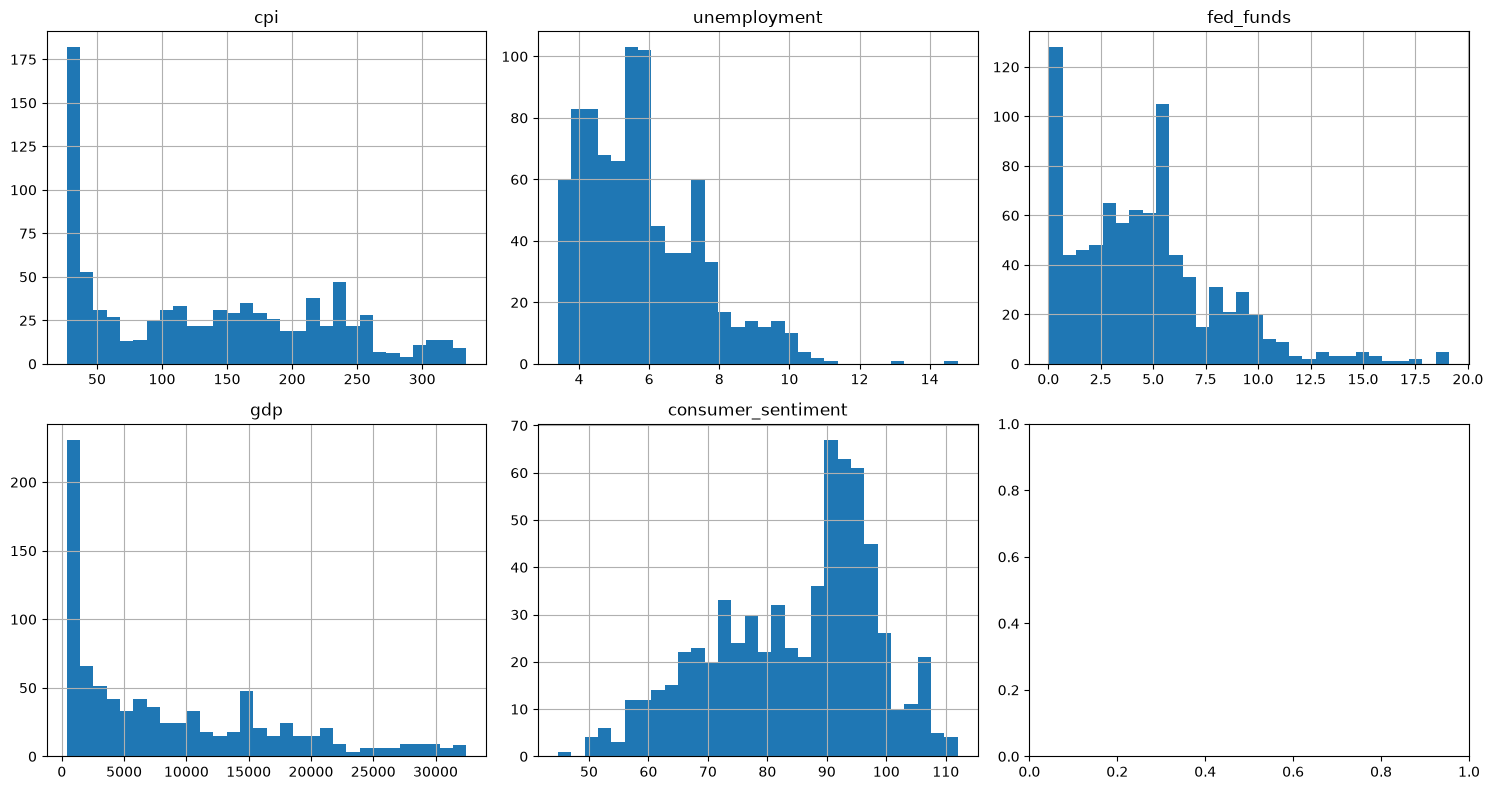

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, ["cpi", "unemployment", "fed_funds", "gdp", "consumer_sentiment"]):
    df[col].hist(ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("data/eda_distributions.png")
plt.show()

Looking at each indicator individually:

CPI and GDP are both strongly right-skewed - most months cluster at lower
historical values with a long tail toward today's much higher numbers.
This makes sense: both are cumulative measures of the economy's size,
which has grown roughly 10x since the 1950s, rather than a rate that
oscillates around a stable average.

Unemployment is closer to a normal distribution but has a long right tail,
with a handful of months spiking above 10% - these correspond to real
recession periods (2008-2009, 2020). The overall spread (std = 1.67) is
much smaller relative to its mean than CPI or GDP, confirming it behaves
like a bounded rate rather than a cumulative index.

Fed funds rate is also right-skewed, with a large concentration of months
near 0%. This visibly confirms two real historical periods of near-zero
interest rate policy (2008-2015 and 2020-2022) as genuine clusters in the
data, not an anomaly.

Consumer sentiment is the most normally distributed of the five, clustering
between roughly 80-95. This fits its design as a bounded survey index,
unlike the other four indicators which are unbounded economic measures.

## 3. Relationship Between Columns

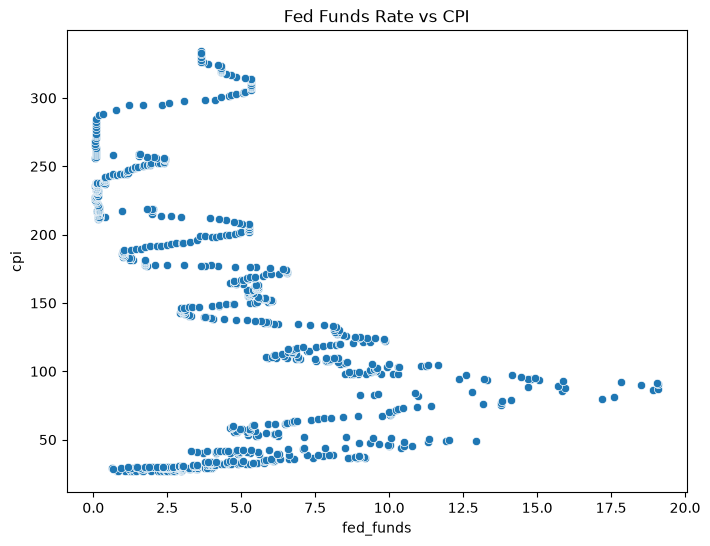

Correlation (fed_funds vs cpi): -0.3843490969839803


In [7]:
df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="fed_funds", y="cpi")
plt.title("Fed Funds Rate vs CPI")
plt.savefig("data/eda_fedfunds_vs_cpi.png")
plt.show()

print("Correlation (fed_funds vs cpi):", df["fed_funds"].corr(df["cpi"]))

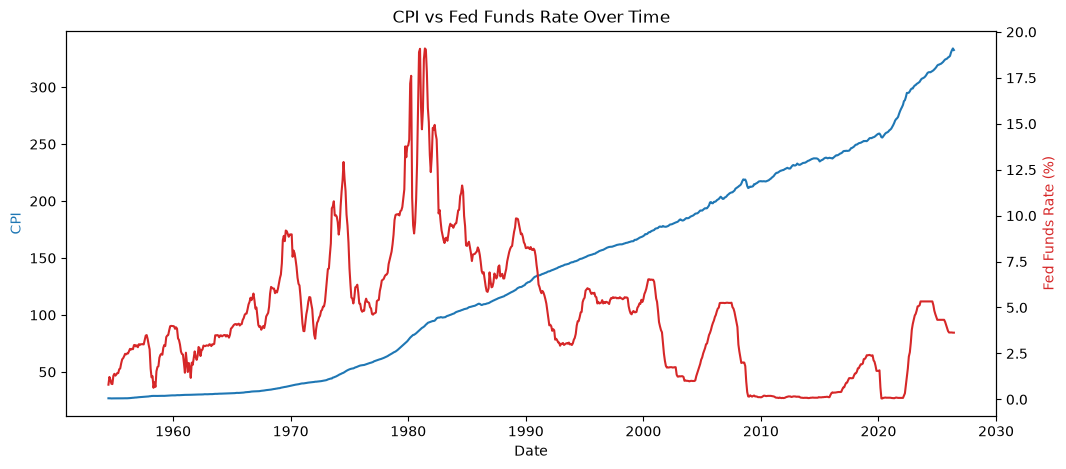

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(df["date"], df["cpi"], color="tab:blue", label="CPI")
ax1.set_ylabel("CPI", color="tab:blue")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(df["date"], df["fed_funds"], color="tab:red", label="Fed Funds Rate")
ax2.set_ylabel("Fed Funds Rate (%)", color="tab:red")

plt.title("CPI vs Fed Funds Rate Over Time")
plt.savefig("data/eda_cpi_vs_fedfunds_time.png")
plt.show()

The scatter plot of fed_funds vs cpi initially appears to show a negative
relationship, but this is misleading on its own: CPI is a cumulative index
that mechanically grows over time regardless of interest rate policy, while
fed_funds rises and falls independently across different decades. The scatter
mixes together very different time periods (e.g. the high-rate 1980s and the
low-rate but high-CPI 2020s), making a simple correlation hard to interpret
correctly.

The time-series chart tells a clearer, more honest story: it shows CPI's
steady long-term rise alongside the Fed's actual rate history, including the
inflation-fighting spike in rates around 1980-1982 and the near-zero rate
periods following the 2008 financial crisis and the 2020 pandemic. This
confirms these two indicators are related through Fed policy responses to
inflation, not through a simple linear correlation.

Correlation coefficient: [insert the number printed under your scatter cell]

Comparing fed_funds and cpi directly (correlation = -0.38) shows a moderate
negative relationship, but the time-series view explains this far better
than the number alone. CPI climbs steadily and almost never reverses,
consistent with its nature as a cumulative price index. The fed funds rate,
by contrast, moves in distinct policy cycles tied to real historical events:
a sharp spike to nearly 20% around 1980-1982 (the Volcker era, fighting
runaway inflation), a drop to near-zero after the 2008 financial crisis,
and another near-zero period during the 2020 pandemic followed by a rapid
climb as the Fed fought post-pandemic inflation.

The moderate correlation reflects that the Fed's rate decisions respond to
inflation with a delay, and are also driven by other events (like 2020's
crisis-driven cut) unrelated to CPI itself. This is a more accurate picture
than the raw scatter plot alone, which mixed together very different decades
and made the relationship look misleadingly straightforward.

## 4. Summary

This dataset combines 5 US macroeconomic indicators from FRED into 863
monthly observations spanning 1954 to 2026: CPI (inflation), unemployment
rate, federal funds rate, GDP, and consumer sentiment.

Key findings before modeling:
- The data is clean: 0 duplicate rows, and validation removed 0 rows -
  the only data-quality issue is 197 rows missing consumer_sentiment,
  which reflects real reporting history rather than an error, and was
  deliberately kept rather than dropped.
- CPI and GDP are strongly right-skewed cumulative measures, while
  unemployment and fed_funds behave more like bounded rates with real
  historical spikes tied to recessions and Fed policy responses.
- Consumer sentiment is the most normally distributed indicator, fitting
  its design as a bounded survey index.
- Fed funds rate and CPI show a moderate negative correlation (-0.38),
  but the true relationship is better understood through their history
  together over time than through a single correlation number, since
  Fed policy responds to inflation with a lag and is sometimes driven
  by unrelated events (like the 2020 pandemic).

These findings inform the machine learning step: fed_funds, unemployment,
gdp, and consumer_sentiment will be used as features to predict CPI, since
each shows a real, explainable economic relationship to inflation rather
than an arbitrary statistical pattern.